In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))

Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\final_model
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


--- CLUSTERING PERFORMANCE ---
          Model  Silhouette  DB_Index
0       K-Means    0.134152  2.482211
1  Hierarchical    0.115708  2.594854
2        DBSCAN    0.193484  1.953290

--- CLASSIFICATION PERFORMANCE ---
                 Model  Accuracy  F1-Score
0                  SVM  0.198333  0.195115
1        Random Forest  0.200000  0.201085
2  Logistic Regression  0.196667  0.187843


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_2280\2728726577.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=class_df, palette='coolwarm')


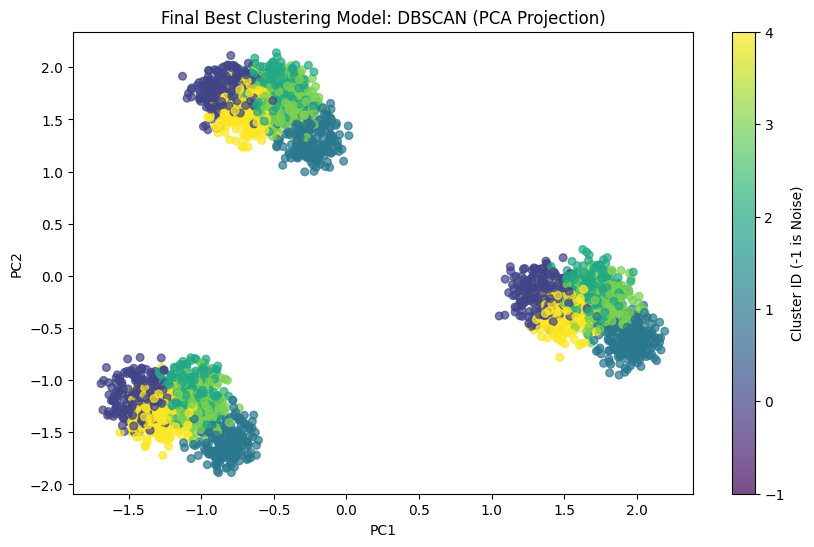

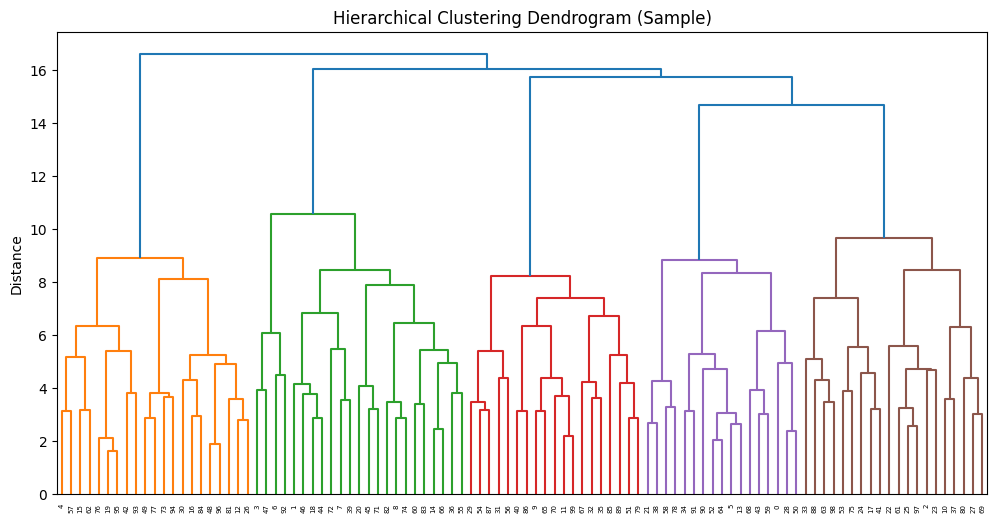

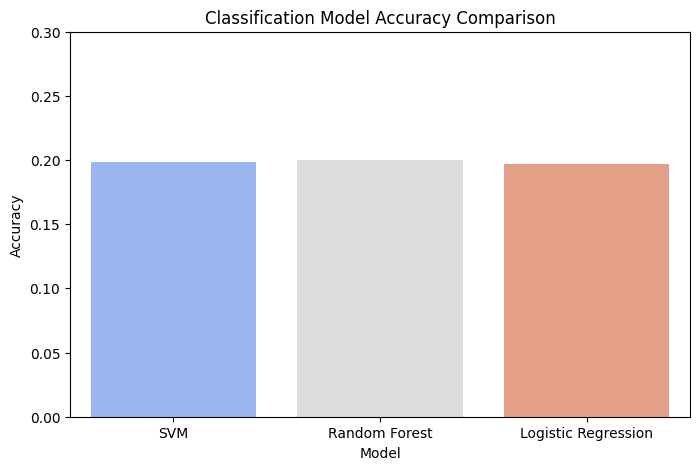

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage


df = pd.read_csv('data/train.csv')
df_proc = df.drop(columns=['Employee_Id'])

# Encoding categorical columns
le = LabelEncoder()
df_proc['Work_Life_Balance'] = le.fit_transform(df_proc['Work_Life_Balance'])
df_proc['Lives_With_Family'] = le.fit_transform(df_proc['Lives_With_Family'])
df_proc = pd.get_dummies(df_proc, columns=['Work_From', 'Working_State'])

# Feature Scaling
X = df_proc.drop(columns=['Stress_Level'])
y = df_proc['Stress_Level']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


cluster_results = []

# K-Means
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
cluster_results.append({
    'Model': 'K-Means', 
    'Silhouette': silhouette_score(X_scaled, km_labels), 
    'DB_Index': davies_bouldin_score(X_scaled, km_labels)
})

# Hierarchical
hier = AgglomerativeClustering(n_clusters=3)
h_labels = hier.fit_predict(X_scaled)
cluster_results.append({
    'Model': 'Hierarchical', 
    'Silhouette': silhouette_score(X_scaled, h_labels), 
    'DB_Index': davies_bouldin_score(X_scaled, h_labels)
})

# DBSCAN
db = DBSCAN(eps=3.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
mask = db_labels != -1 # Exclude noise for metrics
cluster_results.append({
    'Model': 'DBSCAN', 
    'Silhouette': silhouette_score(X_scaled[mask], db_labels[mask]), 
    'DB_Index': davies_bouldin_score(X_scaled[mask], db_labels[mask])
})

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
class_results = []

class_models = {
    'SVM': SVC(probability=True),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

for name, model in class_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    class_results.append({
        'Model': name, 
        'Accuracy': accuracy_score(y_test, y_pred), 
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })


cluster_df = pd.DataFrame(cluster_results)
class_df = pd.DataFrame(class_results)

print("--- CLUSTERING PERFORMANCE ---")
print(cluster_df)
print("\n--- CLASSIFICATION PERFORMANCE ---")
print(class_df)

# Visualization 1: Clustering PCA Plot (Best Model: DBSCAN)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='viridis', s=30, alpha=0.7)
plt.title('Final Best Clustering Model: DBSCAN (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster ID (-1 is Noise)')
plt.savefig('final_clustering_viz.png')

# Visualization 2: Dendrogram (Hierarchical Theory)
plt.figure(figsize=(12, 6))
Z = linkage(X_scaled[:100], method='ward') # Sample of 100
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Sample)')
plt.ylabel('Distance')
plt.savefig('final_dendrogram.png')

# Visualization 3: Classification Accuracy Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=class_df, palette='coolwarm')
plt.title('Classification Model Accuracy Comparison')
plt.ylim(0, 0.3) # Focused view for low-accuracy behavioral data
plt.savefig('final_classification_comparison.png')